In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS
from training_configuration import PATHWAYS_2A

data = "dream_cytof"
filename = "evaluate_all_figure2a"

df = pd.concat(
    pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0).assign(model=model)
    for model in PATHWAYS_2A
)

In [2]:
val_df = df[df.dataset == "val"]
val_df.features.fillna("None", inplace=True)

# Usual CV splits (not used, will be used once I get MDA-MB-468 runs)

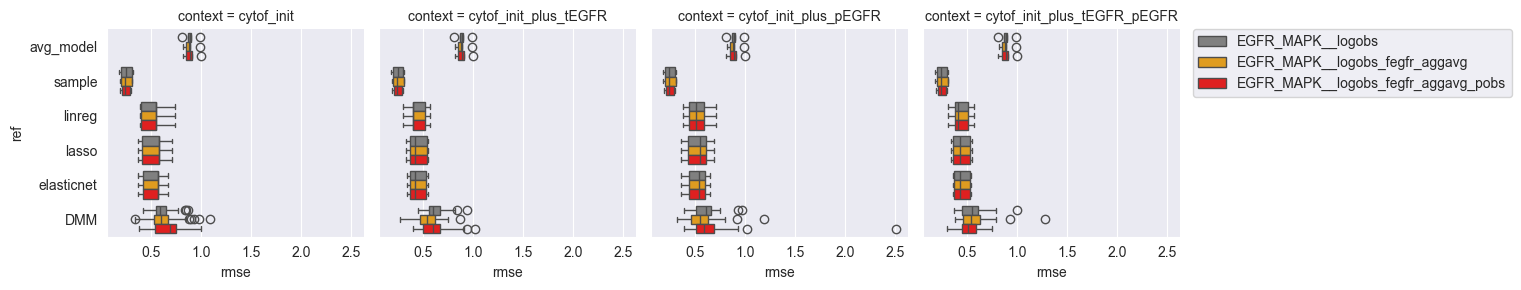

In [3]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_fegfr_aggavg": "orange",
    "EGFR_MAPK__logobs_fegfr_aggavg_pobs": "red",
}

g = sns.FacetGrid(
    val_df,
    col="context",
    col_order=["cytof_init", "cytof_init_plus_tEGFR", "cytof_init_plus_pEGFR", "cytof_init_plus_tEGFR_pEGFR"]
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
    hue="model",
    palette=palette
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# Let's zoom in on DMMs only (regressors are not affected by model choice), comparing model/context combos

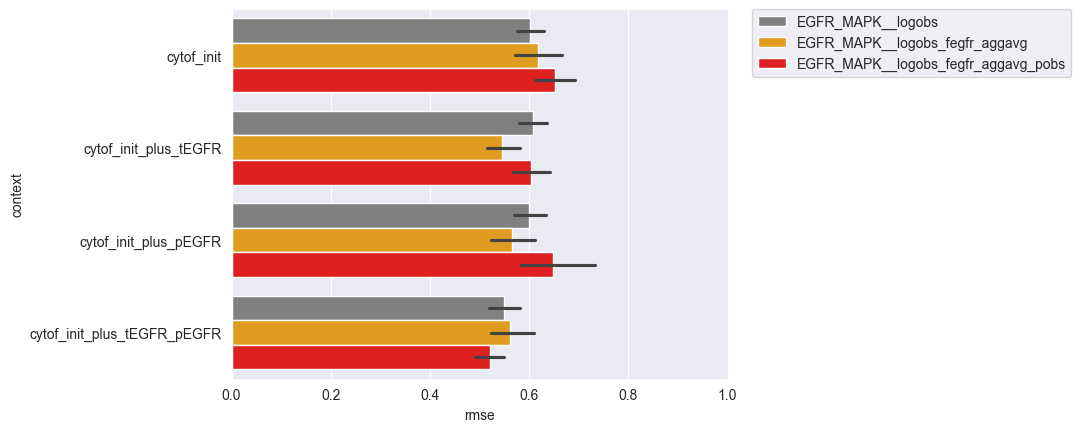

In [4]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_fegfr_aggavg": "orange",
    "EGFR_MAPK__logobs_fegfr_aggavg_pobs": "red",
}

sns.barplot(
    val_df[val_df.ref == "DMM"],
    y="context",
    x="rmse",
    order=["cytof_init", "cytof_init_plus_tEGFR", "cytof_init_plus_pEGFR", "cytof_init_plus_tEGFR_pEGFR"],
    hue="model",
    palette=palette
)
plt.xlim([0, 1])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# Adding fegfr modification to basic cytof_init hurts - just more complexity. Adding the extra bit of `tEGFR` levels, though, helps beat the previous baseline. `pEGFR` helps, but less so, while adding both seems to help even more if adding the `pobs` modification as well. However, `pobs` seems to hurt in all other cases.

# If we look at `samples`-split, we notice we don't really get better on BT-20 (which is what we expected?), but we get better on UACC-3199. Unfortunately, we also get quite worse on EVSA-T.

(0.0, 1.0)

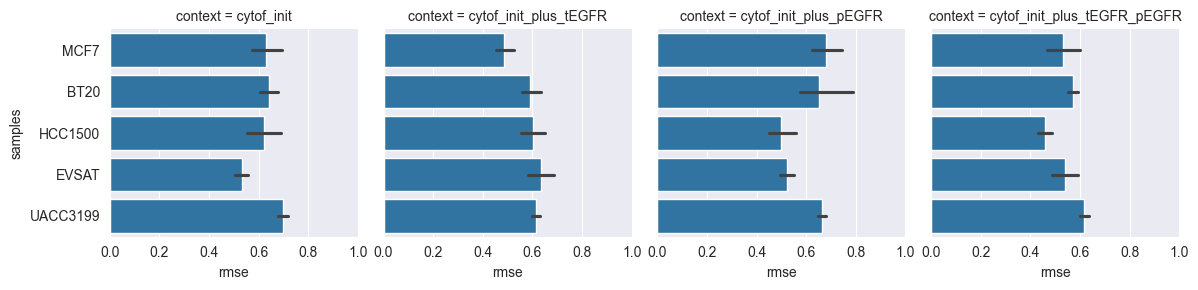

In [5]:
palette = {
    "EGFR_MAPK__logobs": "gray",
    "EGFR_MAPK__logobs_fegfr_aggavg": "orange",
    "EGFR_MAPK__logobs_fegfr_aggavg_pobs": "red",
}

g = sns.FacetGrid(
    val_df[val_df.ref == "DMM"],
    col="context",
    col_order=["cytof_init", "cytof_init_plus_tEGFR", "cytof_init_plus_pEGFR", "cytof_init_plus_tEGFR_pEGFR"],
)

g.map_dataframe(
    sns.barplot,
    x="rmse",
    y="samples",
    order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"],
)

plt.xlim([0, 1])

# Let's restrict to `__logobs_fegr_aggavg` and compare with baselines and regressors

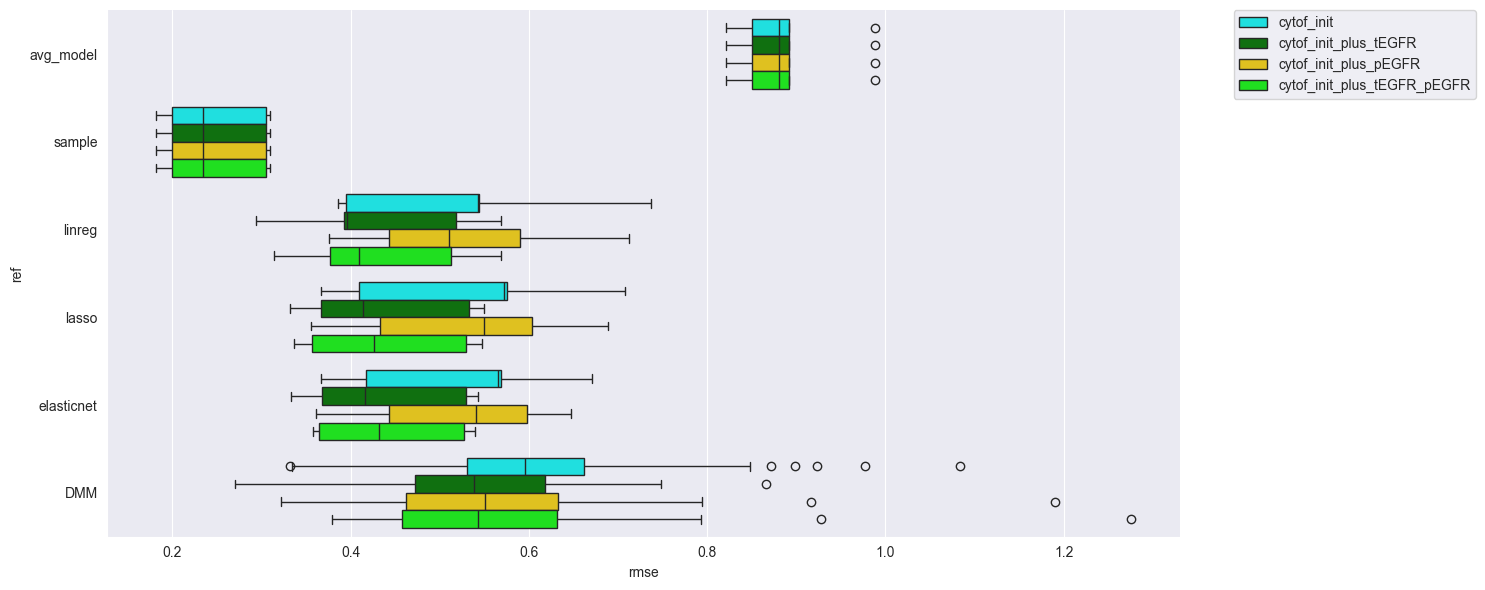

In [6]:
context_palette = {
    "cytof_init": "cyan",
    "cytof_init_plus_tEGFR": "green",
    "cytof_init_plus_pEGFR": "gold",
    "cytof_init_plus_tEGFR_pEGFR": "lime"
}

g = sns.FacetGrid(
    val_df[val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg"],
    height=6,
    aspect=2
)

g.map_dataframe(
    sns.boxplot,
    y="ref",
    x="rmse",
    order=["avg_model", "sample", "linreg", "lasso", "elasticnet", "DMM"],
    hue="context",
    hue_order=["cytof_init", "cytof_init_plus_tEGFR", "cytof_init_plus_pEGFR", "cytof_init_plus_tEGFR_pEGFR"],
    palette=context_palette
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [7]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric):
    for context in df['context'].unique():
        context_data = df[df['context'] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}")

In [8]:
kruskal_wallis_groups(
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_fegfr_aggavg"]))],
    "rmse",
    "model"
)

Context: cytof_init_plus_tEGFR_pEGFR - Kruskal-Wallis H-test: H-statistic=0.01, p-value=0.9396
Context: cytof_init_plus_tEGFR - Kruskal-Wallis H-test: H-statistic=6.97, p-value=0.0083
Context: cytof_init_plus_pEGFR - Kruskal-Wallis H-test: H-statistic=2.81, p-value=0.0939
Context: cytof_init - Kruskal-Wallis H-test: H-statistic=0.03, p-value=0.8686


# Clear improvement in going from `__logobs` to `__logobs_fegfr_aggavg` for `cytof_init_plus_tEGFR`

In [9]:
kruskal_wallis_groups(
    val_df[(val_df.ref.isin(["DMM"])) & (val_df.model.isin(["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_fegfr_aggavg_pobs"]))],
    "rmse",
    "model"
)

Context: cytof_init_plus_tEGFR_pEGFR - Kruskal-Wallis H-test: H-statistic=0.88, p-value=0.3485
Context: cytof_init_plus_tEGFR - Kruskal-Wallis H-test: H-statistic=0.23, p-value=0.6343
Context: cytof_init_plus_pEGFR - Kruskal-Wallis H-test: H-statistic=0.13, p-value=0.7200
Context: cytof_init - Kruskal-Wallis H-test: H-statistic=4.45, p-value=0.0349


But is there an improvement in going from `__logobs` with `cytof_init` to `__logobs_fegfr_aggavg` with `cytof_init_plus_tEGFR`? Or `__logobs_fegfr_aggavg_pobs` with `cytof_init_plus_tEGFR_pEGFR`? Yes, in both cases

In [10]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by="job").rmse.values,
    val_df[(val_df.context == "cytof_init_plus_tEGFR") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg") & (val_df.ref == "DMM")].sort_values(by="job").rmse.values,
]
stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

Kruskal-Wallis H-test: H-statistic=6.26, p-value=0.0123, significant? True


In [11]:
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=393.0, p=0.01758


In [12]:
target_metric = "rmse"
groups = [
    val_df[(val_df.context == "cytof_init") & (val_df.model == "EGFR_MAPK__logobs") & (val_df.ref == "DMM")].sort_values(by="job").rmse.values,
    val_df[(val_df.context == "cytof_init_plus_tEGFR_pEGFR") & (val_df.model == "EGFR_MAPK__logobs_fegfr_aggavg_pobs") & (val_df.ref == "DMM")].sort_values(by="job").rmse.values,
]
stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

Kruskal-Wallis H-test: H-statistic=12.36, p-value=0.0004, significant? True


In [13]:
stat, p = stats.wilcoxon(*groups, alternative="two-sided")
print(f"Wilcoxon signed-rank: W={stat}, p={p:.4g}")

Wilcoxon signed-rank: W=253.0, p=0.000119
